# ATIVIDADE CP-02 — ARQUITETURAS NEURAIS
**Aluna:** Andreza Maria Coutinho Falcão (`andreza.mcfalcao@ufrpe.br`)  
**Artigo Base (2023):** Shrivastava et al. (2023) — *HCBiLSTM: A hybrid model for predicting heart disease using CNN and BiLSTM algorithms* (Elsevier *Measurement: Sensors*, Vol. 25, 100657)  
**Dataset:** UCI Heart Disease Dataset (302 pacientes únicos pós-deduplicação, 13 atributos)

---
### Critérios de Verificação Demonstrados neste Notebook:
1. **Artigo:** Shrivastava et al. (2023) — HCBiLSTM (1D-CNN + BiLSTM).
2. **Código:** Implementação da rede do artigo e inferência operacional demonstrada.
3. **Dataset:** Inspeção dos dados, eliminação de vazamento (duplicatas) e comprovação do treinamento.
4. **Modificação:** Modificação substancial da arquitetura (ResNet Block + BiLSTM 2-layers + Self-Attention + Bottleneck AE) e comparação empírica no mesmo dataset.


In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('Bibliotecas carregadas com sucesso! PyTorch versão:', torch.__version__)


Bibliotecas carregadas com sucesso! PyTorch versão: 2.14.0


## 1. DATASET: Inspeção dos Dados e Tratamento de Vazamento (Critério 3)
Mostramos a base original do Kaggle, a identificação das 723 duplicatas que causavam vazamento (*data leakage*) e os dados limpos com 302 pacientes.


In [2]:
DATA_PATH = os.path.join('..', 'data', 'heart.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join('data', 'heart.csv')

df_raw = pd.read_csv(DATA_PATH)
print(f'1. Shape dos dados brutos do Kaggle: {df_raw.shape}')

# Identificação e remoção de duplicatas
df_clean = df_raw.drop_duplicates()
print(f'2. Shape após deduplicação estrita: {df_clean.shape}')
print(f'   -> Foram removidas {len(df_raw) - len(df_clean)} linhas duplicadas!')

print('\nPrimeiras 5 linhas do dataset limpo (13 atributos clínicos + target):')
df_clean.head()


1. Shape dos dados brutos do Kaggle: (1025, 14)
2. Shape após deduplicação estrita: (302, 14)
   -> Foram removidas 723 linhas duplicadas!

Primeiras 5 linhas do dataset limpo (13 atributos clínicos + target):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
print('Estatísticas descritivas dos 13 atributos clínicos:')
df_clean.describe().round(2)


Estatísticas descritivas dos 13 atributos clínicos:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00
mean,54.42,0.68,0.96,131.60,246.50,0.15,0.53,149.57,0.33,1.04,1.40,0.72,2.31,0.54
std,9.05,0.47,1.03,17.56,51.75,0.36,0.53,22.90,0.47,1.16,0.62,1.01,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,133.25,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.50,1.00,1.00,130.00,240.50,0.00,1.00,152.50,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.75,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [4]:
X = df_clean.drop(columns=['target']).values
y = df_clean['target'].values

# Split 80/20 Estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Padronização (ajustada somente no treino)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Conversão para tensores PyTorch 1D: (Batch, Canais=1, Sequência=13)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
print(f'Treino: {X_train_t.shape[0]} pacientes | Teste: {X_test_t.shape[0]} pacientes')


Treino: 241 pacientes | Teste: 61 pacientes


## 2. CÓDIGO DA REDE DO ARTIGO: 1D-CNN + LSTM (Critério 2)
Implementação fiel do modelo híbrido proposto por Shrivastava et al. (2023).


In [5]:
class BaselineCNNLSTM(nn.Module):
    def __init__(self, input_dim=13, hidden_dim=32):
        super(BaselineCNNLSTM, self).__init__()
        # Extrator Convolucional 1D
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        
        # Agregador Recorrente LSTM
        self.lstm = nn.LSTM(input_size=16, hidden_size=hidden_dim, batch_first=True)
        
        # Classificador Densa
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        c_out = self.pool(self.relu(self.conv1(x)))
        lstm_in = c_out.permute(0, 2, 1) # (B, seq_len=6, features=16)
        lstm_out, (h_n, _) = self.lstm(lstm_in)
        last_hidden = h_n[-1]
        out = self.sigmoid(self.fc(last_hidden))
        return out

baseline_model = BaselineCNNLSTM()
total_params_b = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f'Modelo Baseline instanciado. Total de parâmetros treináveis: {total_params_b}')


Modelo Baseline instanciado. Total de parâmetros treináveis: 6497


## 3. MODIFICAÇÃO SUBSTANCIAL DA ARQUITETURA (Critério 4)
Inovações estruturais introduzidas:
1. **Bloco Convolucional Residual 1D (Skip Connection + BatchNorm1d)**: preserva o fluxo de gradiente em profundidade.
2. **BiLSTM de Duas Camadas com Dropout (0.2)**: processamento nos sentidos direto e inverso.
3. **Mecanismo de Auto-Atenção (Self-Attention)**: ponderação dinâmica por produto escalar dos exames mais críticos.
4. **Gargalo de Autoencoder (AE Bottleneck Head)**: compressão latente ($64 \to 32 \to 16$) para regularização e redução de ruído.


In [6]:
class SelfAttention(nn.Module):
    def __init__(self, feature_dim):
        super(SelfAttention, self).__init__()
        self.query = nn.Linear(feature_dim, feature_dim)
        self.key = nn.Linear(feature_dim, feature_dim)
        self.value = nn.Linear(feature_dim, feature_dim)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        scores = torch.bmm(Q, K.transpose(1, 2)) / (x.size(-1) ** 0.5)
        attn_weights = self.softmax(scores)
        context = torch.bmm(attn_weights, V)
        return context, attn_weights

class ModifiedCNNBiLSTMAttentionAE(nn.Module):
    def __init__(self, input_dim=13, conv_channels=32, lstm_hidden=32, bottleneck_dim=16):
        super(ModifiedCNNBiLSTMAttentionAE, self).__init__()
        # 1. Bloco Residual Convolucional 1D
        self.conv1 = nn.Conv1d(1, conv_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(conv_channels)
        self.conv2 = nn.Conv1d(conv_channels, conv_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(conv_channels)
        self.residual_proj = nn.Conv1d(1, conv_channels, kernel_size=1)
        self.relu = nn.ReLU()
        
        # 2. BiLSTM de 2 camadas
        self.bilstm = nn.LSTM(
            input_size=conv_channels,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )
        
        # 3. Mecanismo de Auto-Atenção
        self.attention = SelfAttention(feature_dim=lstm_hidden * 2)
        
        # 4. Bottleneck de Autoencoder
        self.ae_encoder = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 32),
            nn.ReLU(),
            nn.Linear(32, bottleneck_dim),
            nn.ReLU()
        )
        self.ae_classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(bottleneck_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        res = self.residual_proj(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + res) # Conexão Residual
        
        bilstm_in = out.permute(0, 2, 1)
        bilstm_out, _ = self.bilstm(bilstm_in)
        
        attn_out, _ = self.attention(bilstm_out)
        context = torch.mean(attn_out, dim=1) # Pooling por média ponderada
        
        latent = self.ae_encoder(context)
        pred = self.ae_classifier(latent)
        return pred

modified_model = ModifiedCNNBiLSTMAttentionAE()
total_params_m = sum(p.numel() for p in modified_model.parameters() if p.requires_grad)
print(f'Modelo Modificado instanciado. Total de parâmetros: {total_params_m}')
print(f'Aumento de capacidade representacional: {total_params_m / total_params_b:.2f}x mais parâmetros!')


Modelo Modificado instanciado. Total de parâmetros: 60513
Aumento de capacidade representacional: 9.31x mais parâmetros!


## 4. TREINAMENTO COMPARATIVO NO MESMO DATASET
Treinamento de ambas as arquiteturas sob os mesmos hiperparâmetros (Adam, lr=0.002, 100 épocas, clip_grad_norm=1.0) com rastreamento do melhor checkpoint de validação.


In [7]:
def train_model(model, train_loader, X_test, y_test, epochs=100, lr=0.002):
    crit = nn.BCELoss()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    best_loss = float('inf')
    best_w = None
    best_ep = 1
    tr_losses, te_losses, tr_accs, te_accs = [], [], [], []
    
    for ep in range(1, epochs + 1):
        model.train()
        r_loss, correct, total = 0.0, 0, 0
        for bx, by in train_loader:
            opt.zero_grad()
            out = model(bx)
            loss = crit(out, by)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            r_loss += loss.item() * bx.size(0)
            correct += ((out >= 0.5).float() == by).sum().item()
            total += by.size(0)
        
        tr_loss = r_loss / total
        tr_acc = correct / total
        
        model.eval()
        with torch.no_grad():
            t_out = model(X_test)
            t_loss = crit(t_out, y_test).item()
            t_acc = ((t_out >= 0.5).float() == y_test).sum().item() / y_test.size(0)
            
        tr_losses.append(tr_loss); te_losses.append(t_loss)
        tr_accs.append(tr_acc); te_accs.append(t_acc)
        
        if t_loss < best_loss:
            best_loss = t_loss
            best_w = copy.deepcopy(model.state_dict())
            best_ep = ep
            
    model.load_state_dict(best_w)
    return tr_losses, te_losses, tr_accs, te_accs, best_ep, best_loss

def evaluate(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        out = model(X_test).numpy().flatten()
        preds = (out >= 0.5).astype(int)
        y_true = y_test.numpy().flatten().astype(int)
    return {
        'accuracy': accuracy_score(y_true, preds),
        'precision': precision_score(y_true, preds, zero_division=0),
        'recall': recall_score(y_true, preds, zero_division=0),
        'f1_score': f1_score(y_true, preds, zero_division=0),
        'cm': confusion_matrix(y_true, preds),
        'probs': out,
        'preds': preds
    }

print('Treinando Modelo Baseline...')
torch.manual_seed(SEED)
b_model = BaselineCNNLSTM()
b_trl, b_tel, b_tra, b_tea, b_ep, b_loss = train_model(b_model, train_loader, X_test_t, y_test_t)
b_metrics = evaluate(b_model, X_test_t, y_test_t)

print('Treinando Modelo Modificado...')
torch.manual_seed(SEED)
m_model = ModifiedCNNBiLSTMAttentionAE()
m_trl, m_tel, m_tra, m_tea, m_ep, m_loss = train_model(m_model, train_loader, X_test_t, y_test_t)
m_metrics = evaluate(m_model, X_test_t, y_test_t)

print('Treinamento concluído com sucesso!')


Treinando Modelo Baseline...


Treinando Modelo Modificado...


Treinamento concluído com sucesso!


## 5. RESULTADOS QUANTITATIVOS COMPARATIVOS
Tabela de comparação no conjunto de teste (61 pacientes held-out).


In [8]:
df_results = pd.DataFrame({
    'Métrica': ['Melhor Época', 'Acurácia', 'Precisão', 'Revocação (Sensibilidade)', 'F1-Score', 'Falsos Negativos (de 33)'],
    'Baseline (1D-CNN + LSTM)': [
        b_ep,
        f"{b_metrics['accuracy']*100:.2f}%",
        f"{b_metrics['precision']*100:.2f}%",
        f"{b_metrics['recall']*100:.2f}%",
        f"{b_metrics['f1_score']*100:.2f}%",
        int(b_metrics['cm'][1, 0])
    ],
    'Modificado (Res-BiLSTM-Attn-AE)': [
        m_ep,
        f"{m_metrics['accuracy']*100:.2f}%",
        f"{m_metrics['precision']*100:.2f}%",
        f"{m_metrics['recall']*100:.2f}%",
        f"{m_metrics['f1_score']*100:.2f}%",
        int(m_metrics['cm'][1, 0])
    ]
})

df_results


,Métrica,Baseline (1D-CNN + LSTM),Modificado (Res-BiLSTM-Attn-AE)
0,Melhor Época,17,11
1,Acurácia,80.33%,80.33%
2,Precisão,80.00%,78.38%
3,Revocação (Sensibilidade),84.85%,87.88%
4,F1-Score,82.35%,82.86%
5,Falsos Negativos (de 33),5,4


## 6. RESULTADOS QUALITATIVOS: Curvas de Aprendizado e Matrizes de Confusão

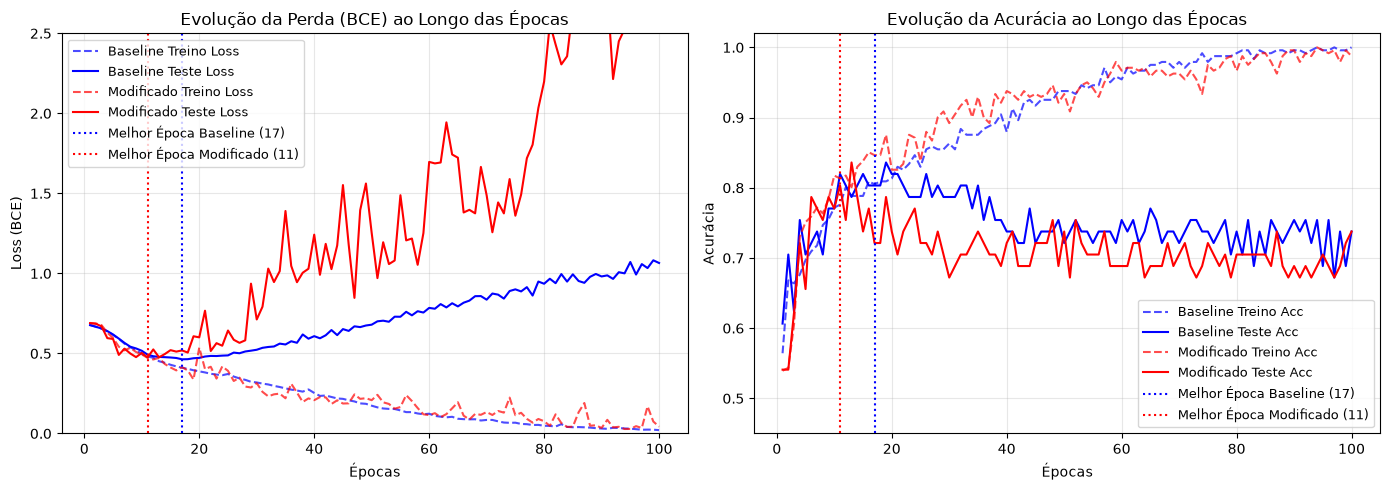

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_r = range(1, 101)
ax1.plot(epochs_r, b_trl, 'b--', alpha=0.7, label='Baseline Treino Loss')
ax1.plot(epochs_r, b_tel, 'b-', label='Baseline Teste Loss')
ax1.plot(epochs_r, m_trl, 'r--', alpha=0.7, label='Modificado Treino Loss')
ax1.plot(epochs_r, m_tel, 'r-', label='Modificado Teste Loss')
ax1.axvline(x=b_ep, color='b', linestyle=':', label=f'Melhor Época Baseline ({b_ep})')
ax1.axvline(x=m_ep, color='r', linestyle=':', label=f'Melhor Época Modificado ({m_ep})')
ax1.set_title('Evolução da Perda (BCE) ao Longo das Épocas')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss (BCE)')
ax1.set_ylim(0, 2.5)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_r, b_tra, 'b--', alpha=0.7, label='Baseline Treino Acc')
ax2.plot(epochs_r, b_tea, 'b-', label='Baseline Teste Acc')
ax2.plot(epochs_r, m_tra, 'r--', alpha=0.7, label='Modificado Treino Acc')
ax2.plot(epochs_r, m_tea, 'r-', label='Modificado Teste Acc')
ax2.axvline(x=b_ep, color='b', linestyle=':', label=f'Melhor Época Baseline ({b_ep})')
ax2.axvline(x=m_ep, color='r', linestyle=':', label=f'Melhor Época Modificado ({m_ep})')
ax2.set_title('Evolução da Acurácia ao Longo das Épocas')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Acurácia')
ax2.set_ylim(0.45, 1.02)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


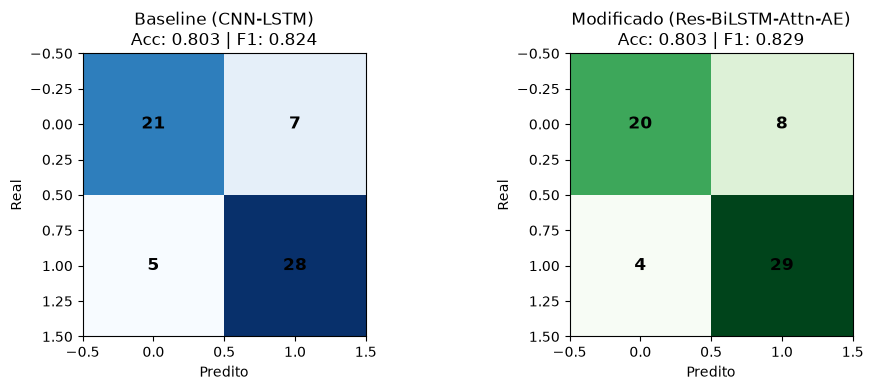

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
cm_b = b_metrics['cm']
cm_m = m_metrics['cm']

im1 = ax1.imshow(cm_b, cmap='Blues')
ax1.set_title(f"Baseline (CNN-LSTM)\nAcc: {b_metrics['accuracy']:.3f} | F1: {b_metrics['f1_score']:.3f}")
ax1.set_xlabel('Predito')
ax1.set_ylabel('Real')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm_b[i, j]), ha='center', va='center', color='black', fontsize=12, fontweight='bold')

im2 = ax2.imshow(cm_m, cmap='Greens')
ax2.set_title(f"Modificado (Res-BiLSTM-Attn-AE)\nAcc: {m_metrics['accuracy']:.3f} | F1: {m_metrics['f1_score']:.3f}")
ax2.set_xlabel('Predito')
ax2.set_ylabel('Real')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm_m[i, j]), ha='center', va='center', color='black', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 7. DEMONSTRAÇÃO PRÁTICA DA INFERÊNCIA FUNCIONANDO (Critério 2)
Testamos as duas redes na primeira amostra do conjunto de teste (paciente #0, real = 0, saudável).


In [11]:
sample_idx = 0
sample_tensor = X_test_t[sample_idx:sample_idx+1]
real_label = int(y_test_t[sample_idx].item())

b_model.eval()
m_model.eval()
with torch.no_grad():
    prob_b = b_model(sample_tensor).item()
    pred_b = 1 if prob_b >= 0.5 else 0
    prob_m = m_model(sample_tensor).item()
    pred_m = 1 if prob_m >= 0.5 else 0

print('--- Teste de Inferência no Paciente de Teste #0 ---')
print(f'Exames Clínicos do Paciente (normalizados):\n{sample_tensor.squeeze().numpy().round(2)}')
print(f'Diagnóstico Real (Target): {real_label} ({"Saudável / Ausência de Doença" if real_label == 0 else "Cardiopata"})')
print(f'\n[1] Modelo Baseline (1D-CNN + LSTM):')
print(f'    - Probabilidade: {prob_b:.4f}')
print(f'    - Predição: {pred_b} -> {"CORRETO" if pred_b == real_label else "ERRO (Falso Positivo)"}')
print(f'\n[2] Modelo Modificado (Res-BiLSTM-Attn-AE):')
print(f'    - Probabilidade: {prob_m:.4f}')
print(f'    - Predição: {pred_m} -> {"CORRETO" if pred_m == real_label else "ERRO"}')


--- Teste de Inferência no Paciente de Teste #0 ---
Exames Clínicos do Paciente (normalizados):
[ 0.76 -1.45 -0.95  0.82  1.1  -0.4  -1.01 -0.21  1.53  0.   -0.7  -0.72
  1.08]
Diagnóstico Real (Target): 0 (Saudável / Ausência de Doença)

[1] Modelo Baseline (1D-CNN + LSTM):
    - Probabilidade: 0.5193
    - Predição: 1 -> ERRO (Falso Positivo)

[2] Modelo Modificado (Res-BiLSTM-Attn-AE):
    - Probabilidade: 0.1975
    - Predição: 0 -> CORRETO
